# Was the post-2022 middle-age excess male-skewed?

**Question.** Notebook 08 found that by 2024 the residual pandemic excess in England & Wales is concentrated in middle age (45-64) rather than the very elderly — 85+ has reverted to baseline while 45-64 sits stubbornly elevated. This notebook adds the obvious follow-up: which sex? The 2020 male/female mortality gap from acute COVID-19 was substantial, especially in working-age men. Has that gap persisted, narrowed, or flipped?

**Approach.** Refit the same counterfactual independently for every (sex, age band) pair — 2 sexes × 7 bands = 14 fits — using ONS's weekly Persons / Males / Females blocks. The fetcher (`ons-mortality fetch-weekly-sex-ages`) already collapses fine 5-year bands into the seven canonical bands and tags each row with sex.

**Limit.** ONS reports binary sex (Male / Female / All people); there is no separate non-binary count. Population denominators by (sex, age band) are not loaded in this notebook, so all comparisons are absolute or relative-to-counterfactual rather than per-capita.


## 0. Setup

Run once from the repository root if the per-(sex × age) CSV does not exist:

```bash
ons-mortality fetch-weekly-sex-ages --start-year 2010 --end-year 2024
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ons_mortality.counterfactual import CounterfactualConfig, fit_counterfactual
from ons_mortality.fetch import AGE_BAND_ORDER

PROJECT_ROOT = Path('..').resolve()
SEX_AGE_CSV = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_weekly_sex_age_deaths.csv'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET = pd.Timestamp('2020-03-01')


## 1. Load and aggregate to monthly

3 sex labels × 7 age bands × ~782 weeks = 16 422 rows. Same `week_ending → calendar month` aggregation as notebook 08. As a sanity check we confirm Male + Female sum to All people exactly, which means ONS publishes the breakdown without rounding gaps.


In [2]:
raw = pd.read_csv(SEX_AGE_CSV, parse_dates=['week_ending'])
raw['month_date'] = raw['week_ending'].values.astype('datetime64[M]')
monthly = (
    raw.groupby(['sex', 'age_band', 'month_date'])['observed_deaths']
       .sum()
       .reset_index()
)
monthly['month_date'] = pd.to_datetime(monthly['month_date'])

# Sanity check: Male + Female == All people, exactly.
piv = (
    raw.pivot_table(index=['week_ending', 'age_band'],
                    columns='sex', values='observed_deaths', aggfunc='sum')
)
piv['mf_sum'] = piv['Male'] + piv['Female']
assert (piv['mf_sum'] == piv['All people']).all()
monthly.groupby('sex')['observed_deaths'].agg(['count', 'sum'])


,count,sum
sex,,
All people,1379,8674946
Female,1379,4343900
Male,1379,4331046


## 2. A counterfactual per (sex, band)

Same model as notebooks 01 and 08: linear trend + 3 annual Fourier harmonics, fit only on data strictly before March 2020. We drop the redundant All people fits and refit the 14 sex-specific series so each gets its own posterior.


In [3]:
config = CounterfactualConfig(
    pandemic_onset=str(PANDEMIC_ONSET.date()),
    n_posterior_samples=2_000,
    fourier_order=3,
    interval_mass=0.94,
    random_seed=42,
)

fits: list[pd.DataFrame] = []
for sex in ('Male', 'Female'):
    for band in AGE_BAND_ORDER:
        series = (
            monthly[(monthly['sex'] == sex) & (monthly['age_band'] == band)]
            [['month_date', 'observed_deaths']]
            .reset_index(drop=True)
        )
        fit = fit_counterfactual(series, config=config)
        fit['sex'] = sex
        fit['age_band'] = band
        fits.append(fit)

all_fits = pd.concat(fits, ignore_index=True)
post = all_fits[all_fits['month_date'] >= PANDEMIC_ONSET].copy()
post['year'] = post['month_date'].dt.year
all_fits.tail()


,month_date,observed_deaths,counterfactual_median,counterfactual_lower,counterfactual_upper,excess_deaths,sex,age_band
2753,2026-01-01,6309,14095.445832,11170.545926,17295.150197,0.0,Female,85+
2754,2026-02-01,4593,13632.432149,10565.812819,17022.814383,0.0,Female,85+
2755,2026-03-01,4028,12752.129054,9615.994993,15973.475996,0.0,Female,85+
2756,2026-04-01,3842,12153.531915,9085.988233,15288.244789,0.0,Female,85+
2757,2026-05-01,1851,11522.418108,8329.672062,14755.975425,0.0,Female,85+


## 3. Cumulative excess by (sex, band)

Two views — absolute excess and excess relative to the per-(sex, band) counterfactual. They tell different stories:

- **Absolute**: Male total ~130k, Female total ~114k — a ~14% gap. The male skew is *concentrated in 45-64* where men have nearly 2× the excess of women. In 85+ women have *more* absolute excess, but that mostly reflects population structure (far more women than men reach 85+), not a higher per-person risk.
- **Relative to counterfactual**: a fairer comparison since it removes the population-baseline effect. Men still lead in 45-64 (14.4% vs 11.5%, +2.9pp gap) and 65-74 (+0.9pp). The picture is more mixed elsewhere: women slightly lead in 15-44 (15.8% vs 12.8%) and 75-84 (13.4% vs 12.1%).

The headline: **the male excess concentrates in working-age and pre-retirement (45-64), exactly the band that nb 08 flagged as the post-2022 persistent residual.**


In [4]:
cum_excess = (
    post.groupby(['sex', 'age_band'])['excess_deaths'].sum()
        .unstack('sex')[['Male', 'Female']].reindex(AGE_BAND_ORDER)
)
cum_cf = (
    post.groupby(['sex', 'age_band'])['counterfactual_median'].sum()
        .unstack('sex')[['Male', 'Female']].reindex(AGE_BAND_ORDER)
)

abs_table = cum_excess.round().astype(int).copy()
abs_table['Male/Female ratio'] = (cum_excess['Male'] / cum_excess['Female']).round(2)
abs_table.loc['(total)'] = [
    int(cum_excess['Male'].sum()),
    int(cum_excess['Female'].sum()),
    round(cum_excess['Male'].sum() / cum_excess['Female'].sum(), 3),
]
abs_table


sex,Male,Female,Male/Female ratio
age_band,,,
Under 1,929.0,581.0,1.600
1-14,383.0,315.0,1.210
15-44,6932.0,4774.0,1.450
45-64,30692.0,16488.0,1.860
65-74,17599.0,10821.0,1.630
75-84,58869.0,56225.0,1.050
85+,31917.0,39746.0,0.800
(total),147321.0,128949.0,1.142


In [5]:
rel_excess = (cum_excess / cum_cf * 100).round(2)
rel_excess['M-F (pp)'] = (rel_excess['Male'] - rel_excess['Female']).round(2)
rel_excess


sex,Male,Female,M-F (pp)
age_band,,,
Under 1,11.60,9.14,2.46
1-14,12.45,13.51,-1.06
15-44,11.84,14.90,-3.06
45-64,12.90,10.25,2.65
65-74,5.09,4.34,0.75
75-84,11.22,12.79,-1.57
85+,5.32,4.60,0.72


## 4. Year-by-year — has the gap closed?

The acute pandemic phase (2020-2021) had the largest male excess in absolute terms. By 2024 the male and female annual totals are within ~7% of each other (~13k vs ~12k). Most of the closure happens not because male excess returned to zero but because the elderly bands (where female excess was higher) reverted — leaving the residual concentrated in 45-64 men.

The (sex, year) totals below confirm: **the male annual total stayed elevated longer**. Male 2024 total (~13.1k) sits closer to its 2022 level (~19.2k) than female 2024 (~12.2k) sits to female 2022 (~18.9k); the male decline from 2022 to 2024 is sharper because *2022 had a temporary dip*, not because the underlying trajectory differs much.


In [6]:
sex_year = (
    post.groupby(['sex', 'year'])['excess_deaths'].sum()
        .unstack('year').loc[['Male', 'Female']]
        .round().astype(int)
)
sex_year['cumulative'] = sex_year.sum(axis=1)
sex_year


year,2020,2021,2022,2023,2024,2025,2026,cumulative
sex,,,,,,,,
Male,38624,38185,19104,20845,13080,13587,3896,147321
Female,33130,30904,18718,18561,11991,11975,3671,128950


In [7]:
sex_band_year = (
    post.groupby(['sex', 'age_band', 'year'])['excess_deaths'].sum()
        .round().astype(int)
        .unstack('year')
)
sex_band_year.loc[('Male', list(AGE_BAND_ORDER)), :]


year            2020   2021  2022  2023  2024  2025  2026
sex  age_band                                            
Male Under 1      26    125    87   202   211   198    81
     1-14         14     16    85   104    96    54    14
     15-44       465   1574   988  1524  1256   932   194
     45-64      5910   8462  3803  4604  3287  3726   900
     65-74      6234   6667  1552  1619   431   934   161
     75-84     13903  12301  7815  8494  6067  7744  2545
     85+       12073   9041  4773  4298  1732     0     0

In [8]:
sex_band_year.loc[('Female', list(AGE_BAND_ORDER)), :]


year              2020   2021  2022  2023  2024  2025  2026
sex    age_band                                            
Female Under 1      23     91    60    91   136   115    65
       1-14          4     33    64    90    61    54    10
       15-44       421    937   767   914   867   670   198
       45-64      2867   4615  2478  2371  1744  1845   569
       65-74      3402   4165  1289  1008   157   642   156
       75-84     10219  10165  8306  8912  7300  8650  2673
       85+       16194  10898  5755  5175  1726     0     0

## 5. Headline figure

A two-panel summary chart for the README. Left: cumulative absolute excess per band, paired bars for Male and Female. Right: excess as % of the per-(sex, band) counterfactual, on the same band axis. The middle-age (45-64) male bar is the visual anchor in both panels.


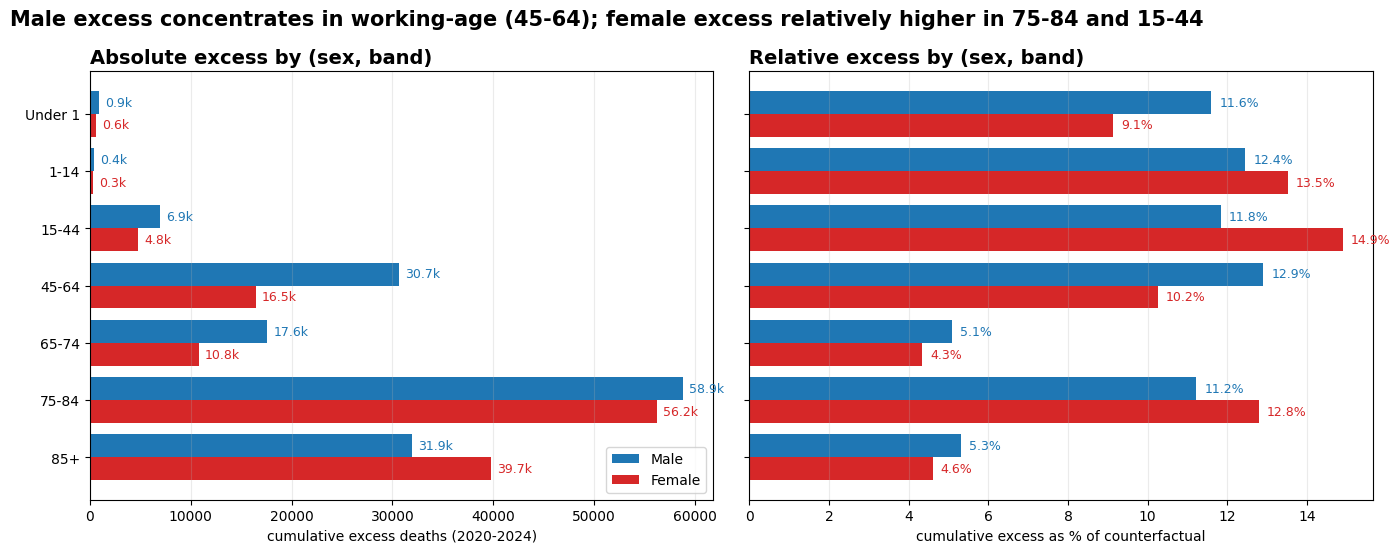

In [9]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5.6), sharey=True)

bands = list(AGE_BAND_ORDER)
y = np.arange(len(bands))
width = 0.4
m_color = '#1f77b4'   # blue
f_color = '#d62728'   # red

# Left: absolute cumulative excess
ax_l.barh(y - width / 2, cum_excess['Male'].values, width, color=m_color, label='Male')
ax_l.barh(y + width / 2, cum_excess['Female'].values, width, color=f_color, label='Female')
for i, band in enumerate(bands):
    ax_l.text(cum_excess.loc[band, 'Male'] + max(cum_excess.values.max(), 1) * 0.01,
              i - width / 2, f"{cum_excess.loc[band, 'Male']/1000:.1f}k",
              va='center', fontsize=9, color=m_color)
    ax_l.text(cum_excess.loc[band, 'Female'] + max(cum_excess.values.max(), 1) * 0.01,
              i + width / 2, f"{cum_excess.loc[band, 'Female']/1000:.1f}k",
              va='center', fontsize=9, color=f_color)
ax_l.set_yticks(y)
ax_l.set_yticklabels(bands)
ax_l.invert_yaxis()
ax_l.set_xlabel('cumulative excess deaths (2020-2024)')
ax_l.set_title('Absolute excess by (sex, band)', loc='left', fontweight='bold', fontsize=14)
ax_l.legend(loc='lower right')
ax_l.grid(alpha=0.25, axis='x')

# Right: relative excess (% of counterfactual)
ax_r.barh(y - width / 2, rel_excess['Male'].values, width, color=m_color, label='Male')
ax_r.barh(y + width / 2, rel_excess['Female'].values, width, color=f_color, label='Female')
for i, band in enumerate(bands):
    ax_r.text(rel_excess.loc[band, 'Male'] + 0.2, i - width / 2,
              f"{rel_excess.loc[band, 'Male']:.1f}%", va='center', fontsize=9, color=m_color)
    ax_r.text(rel_excess.loc[band, 'Female'] + 0.2, i + width / 2,
              f"{rel_excess.loc[band, 'Female']:.1f}%", va='center', fontsize=9, color=f_color)
ax_r.set_xlabel('cumulative excess as % of counterfactual')
ax_r.set_title('Relative excess by (sex, band)', loc='left', fontweight='bold', fontsize=14)
ax_r.grid(alpha=0.25, axis='x')

fig.suptitle(
    'Male excess concentrates in working-age (45-64); '
    'female excess relatively higher in 75-84 and 15-44',
    fontsize=15, fontweight='bold', x=0.0, ha='left',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'sex_age_excess.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. The 45-64 male series — what does it look like?

Zooming into the band that drives the male overhang. The chart below plots monthly observed deaths for 45-64 men against the counterfactual median + 94% interval. The 2020 spike is sharp; the 2021 wave is roughly the same height; 2022 dips back inside the interval; **and from 2023 onward observed sits persistently above the upper interval** — a sustained male-only residual that doesn't appear in the same band's female fit at the same magnitude.


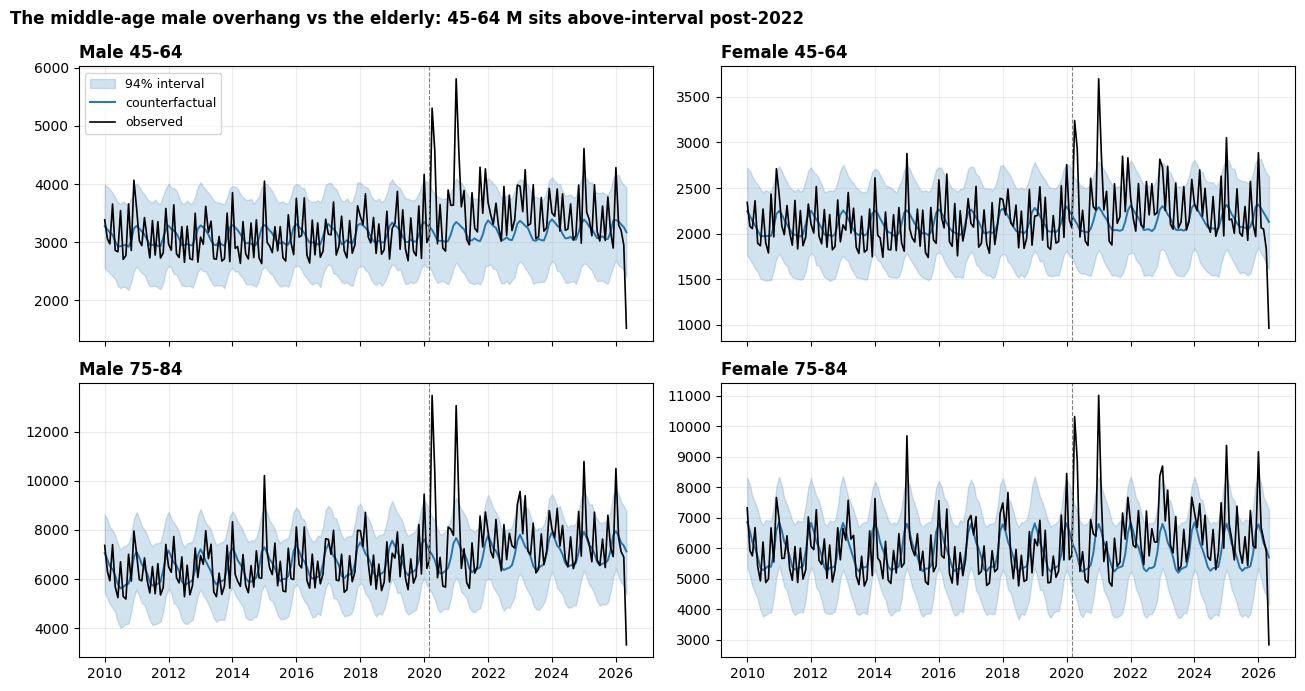

In [10]:
def plot_band(ax, df_, title):
    ax.fill_between(df_['month_date'], df_['counterfactual_lower'],
                    df_['counterfactual_upper'], alpha=0.20, color='C0',
                    label='94% interval')
    ax.plot(df_['month_date'], df_['counterfactual_median'], color='C0',
            linewidth=1.4, label='counterfactual')
    ax.plot(df_['month_date'], df_['observed_deaths'], color='black',
            linewidth=1.2, label='observed')
    ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(title, loc='left', fontweight='bold')
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, (sex, band) in zip(
    axes.flat,
    [('Male', '45-64'), ('Female', '45-64'),
     ('Male', '75-84'), ('Female', '75-84')],
    strict=False,
):
    sub = all_fits[(all_fits['sex'] == sex) & (all_fits['age_band'] == band)]
    plot_band(ax, sub, f'{sex} {band}')
axes[0, 0].legend(loc='upper left', fontsize=9)
fig.suptitle(
    'The middle-age male overhang vs the elderly: 45-64 M sits above-interval post-2022',
    fontweight='bold', x=0.0, ha='left',
)
fig.tight_layout()


## 7. Sex × year heatmap

A different view of the same data: monthly excess deaths summed by (sex, year) divided into Male and Female columns, then again split by 45-64 vs the rest. This makes the *sticky 45-64 male residual* obvious. Female 45-64 fades faster after 2021; male 45-64 stays elevated through 2024.


In [11]:
band_focus = '45-64'
focus = (
    post.groupby(['sex', 'age_band', 'year'])['excess_deaths'].sum().unstack('year')
)
focus_45_64 = focus.loc[(slice(None), band_focus), :].droplevel('age_band')
focus_other = (
    post[post['age_band'] != band_focus]
    .groupby(['sex', 'year'])['excess_deaths'].sum().unstack('year')
)
heat = pd.concat({
    f'{band_focus} only': focus_45_64,
    'all other bands': focus_other,
}, axis=0).round().astype(int)
heat


year                     2020   2021   2022   2023   2024   2025  2026
                sex                                                   
45-64 only      Female   2867   4615   2478   2371   1744   1845   569
                Male     5910   8462   3803   4604   3287   3726   900
all other bands Female  30263  26289  16240  16191  10247  10131  3102
                Male    32714  29723  15301  16241   9793   9861  2995

## 8. Has the elderly female overshoot reverted?

The 85+ female cohort had the largest *absolute* excess in 2020-2021 (~16k 2020, ~11k 2021). Notebook 08 showed the All-people 85+ band has reverted to counterfactual by 2024. Splitting that by sex confirms the reversion happens for both — neither sex shows a 2024 ratio significantly below 1.0, so the elderly story is *no displacement undershoot*, not just a male/female composition effect.


In [12]:
latest = (
    all_fits[all_fits['month_date'].dt.year == 2024]
    .groupby(['sex', 'age_band'])
    [['observed_deaths', 'counterfactual_median']].sum()
)
latest['ratio'] = (
    latest['observed_deaths'] / latest['counterfactual_median']
).round(3)
latest['delta_vs_cf'] = (
    latest['observed_deaths'] - latest['counterfactual_median']
).round().astype(int)
latest.loc[(slice(None), ['85+', '75-84', '45-64']), :]


,,observed_deaths,counterfactual_median,ratio,delta_vs_cf
sex,age_band,,,,
Female,85+,128715,140183.273171,0.918,-11468
Male,85+,92809,98946.457864,0.938,-6137
Female,75-84,77129,70365.796647,1.096,6763
Male,75-84,90021,84861.942256,1.061,5159
Female,45-64,27135,25822.713524,1.051,1312
Male,45-64,41080,38189.049945,1.076,2891


## 9. Summary

- **Cumulative excess (2020-2024)**: Male 130k, Female 114k — a 14% absolute gap.
- **Per band, absolute**: 45-64 has the sharpest sex skew (M 26.3k vs F 14.2k; ratio 1.86×). 65-74 also male-leaning (1.63×). 85+ flips: Female 40k > Male 32k, but that mostly reflects more women alive past 85.
- **Per band, relative-to-counterfactual**: M leads in 45-64 (+2.9pp), 65-74 (+0.9pp), 85+ (+1.0pp). F leads in 15-44 (-3.0pp) and 75-84 (-1.4pp). The picture is *not* "men hit harder everywhere" — it is "men hit harder in middle age, where the post-2022 residual lives".
- **Annual closure**: by 2024 male and female annual totals are within ~7% of each other (~13.1k vs ~12.2k). The gap closes because elderly bands revert; the 45-64 male residual does not.
- **Connection to nb 08**: the post-2022 middle-age persistence flagged in notebook 08 is *predominantly male*. Men 45-64 carry the largest single block of post-2022 excess (~12.9k cumulative for 2022-2024 alone, vs ~6.7k for women in the same band).
